In [1]:
import pandas as pd
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

In [28]:
csv_data = read_csv("annot_done_p1.csv")
#display(csv_data)
age_df = csv_data.dropna(subset=["annotation"])
display(age_df)

,image_name,annotation
0,A1987-05029c.JPG,9.0
1,a20075259.jpg,3.0
2,c200605281.jpg,10.0
3,c200605286.jpg,12.0
4,2020-02.jpg,8.0
5,A1987-05029d.JPG,8.0
8,A1995-05098.jpg,3.0
9,A2005-05290c.JPG,10.0
10,A2005-05290d.JPG,10.0
12,a200705261.jpg,4.0


In [ ]:
path = "Joel"
for filename in os.listdir(path):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        image_path = os.path.join(path, filename)
        match = age_df[age_df["image_name"] == filename]
        
        if not match.empty:
            annotation = match["annotation"].values[0]
            img = Image.open(image_path)
            plt.imshow(img)
            plt.title(f"{filename} - Annotation: {annotation}")
            plt.axis("off")
            plt.show()
            
        else:
            img = Image.open(image_path)
            plt.imshow(img)
            plt.title(f'NO LABEL FOR {filename}')
            plt.axis("off")
            plt.show()
            print('Unlabeled Image')

Creating a dataset by just adding _n (1, 2, 3) to every image generating a new dataframe, appending the original age to corresponding sample

In [ ]:
csv_data = read_csv("annot_done_p1.csv")
age_df = csv_data.dropna(subset=["annotation"])

crop_rows = []

for i in range(len(age_df)):
    row = age_df.iloc[i]
    base_name = row["image_name"].lower().replace(".jpg", "")
    #print(row["image_name"])
    for i in range(1, 4):
        new_filename = f"{base_name}_{i}.jpg"
       # print(new_filename)
        crop_rows.append({"image": new_filename, "age": row["annotation"]})
    #print("-"*50)

crop_df = pd.DataFrame(crop_rows)
display(crop_df)

,image,age
0,a1987-05029c_1.jpg,9.0
1,a1987-05029c_2.jpg,9.0
2,a1987-05029c_3.jpg,9.0
3,a20075259_1.jpg,3.0
4,a20075259_2.jpg,3.0
...,...,...
97,c200605283_2.jpg,11.0
98,c200605283_3.jpg,11.0
99,c200605380_1.jpg,4.0
100,c200605380_2.jpg,4.0


fetching images using our DF, plotting each (theres a lot of plots)

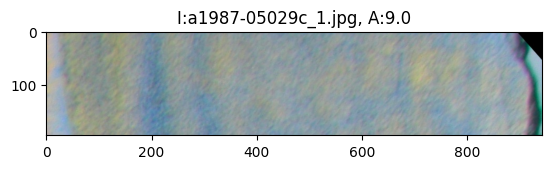

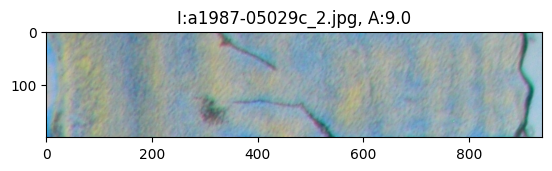

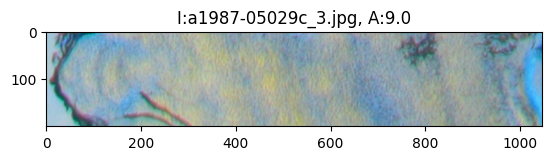

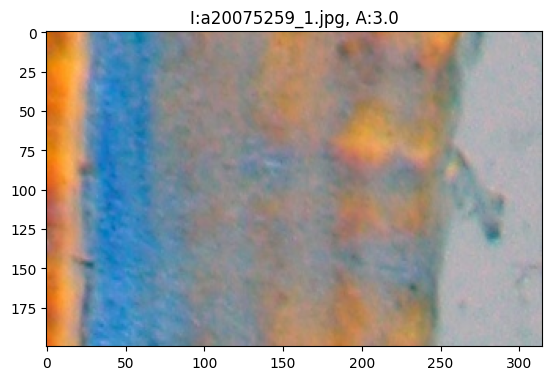

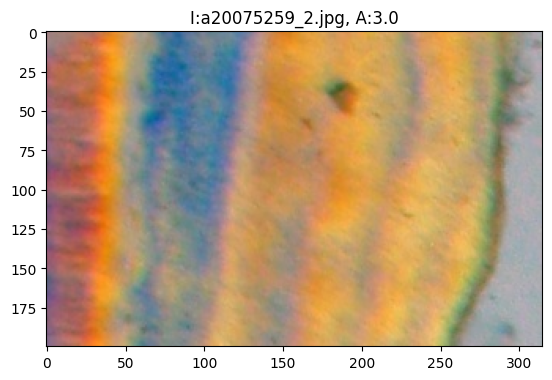

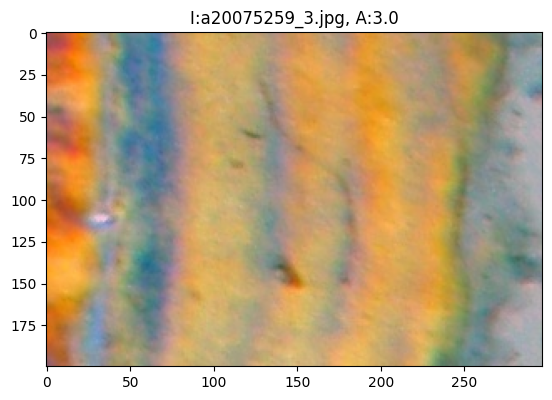

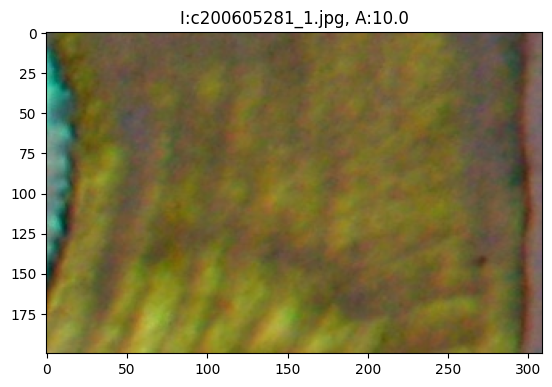

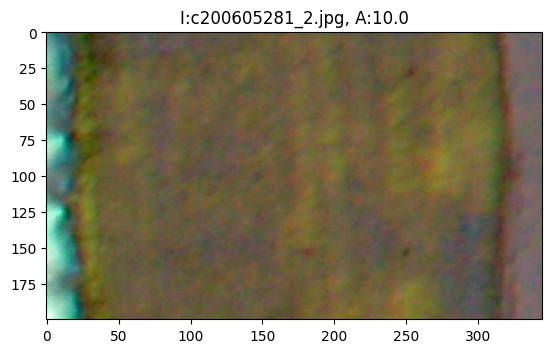

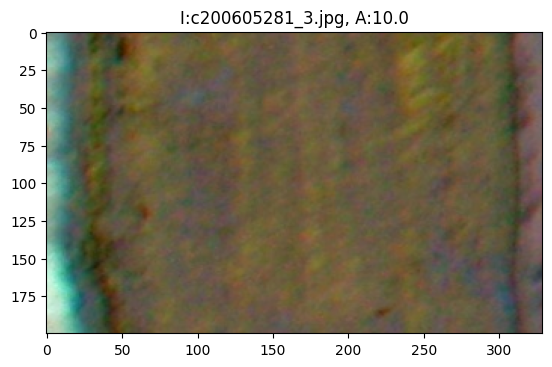

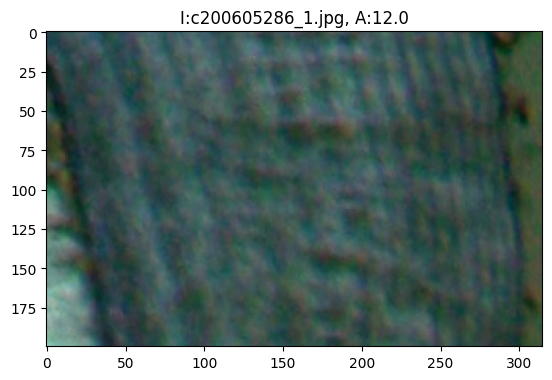

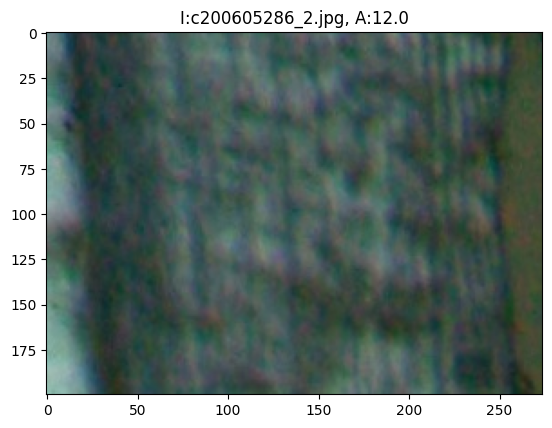

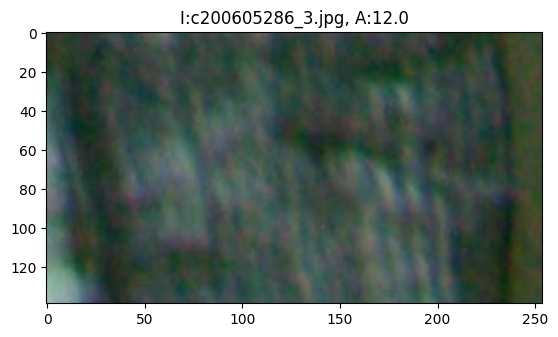

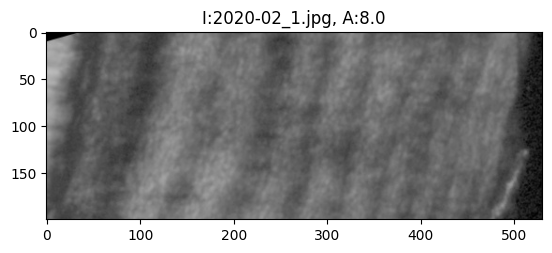

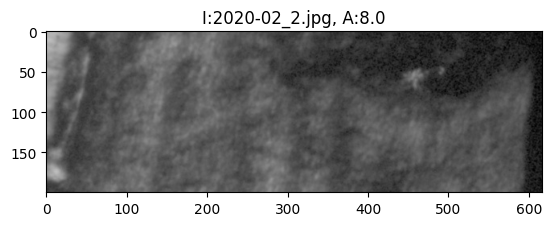

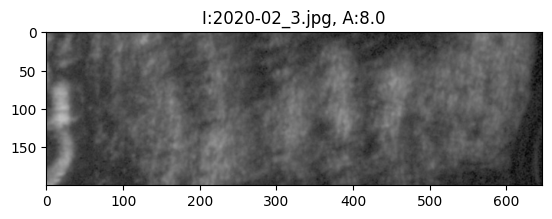

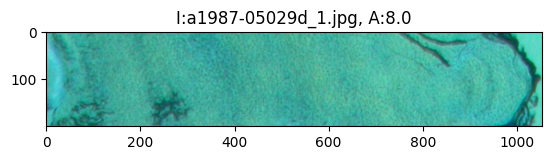

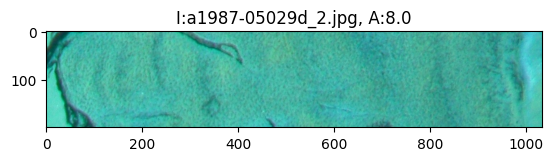

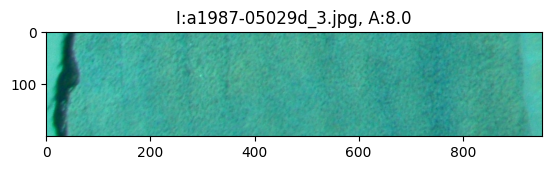

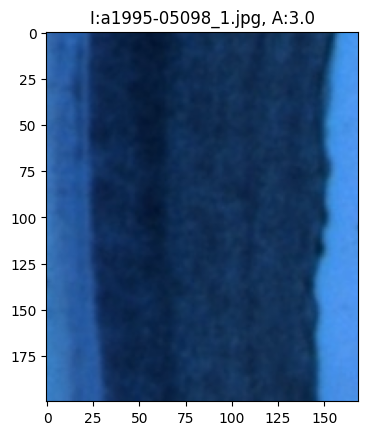

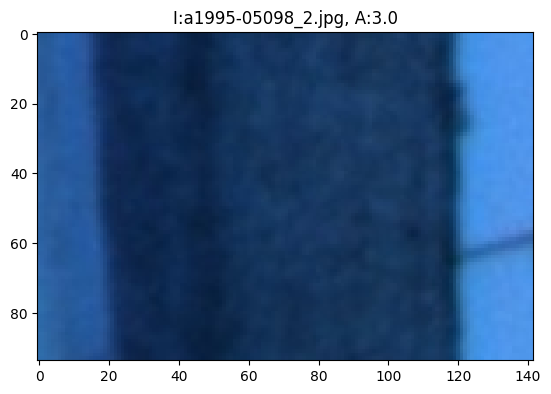

In [29]:
for i in range(len(crop_df)):
    if i < 20:
        row = crop_df.iloc[i]
        img_name = row['image']
        img_age = row['age']
        image = Image.open(f"NewImages/{row['image']}")
        plt.imshow(image)
        plt.title(f'I:{img_name}, A:{img_age}')
        plt.show()
